# Gaussian Elimination with Partial Pivoting
> **Numerical Methods for Engineering** | Module 02 - Linear Systems | `01_Gaussian_Elimination.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/02-Linear-Systems/01_Gaussian_Elimination.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- Formulate an engineering problem as a system $A\mathbf{x} = \mathbf{b}$ of $n$ linear equations.
- Describe the **forward elimination** and **back substitution** phases of Gaussian elimination.
- Explain why **partial pivoting** is essential for numerical stability.
- Count the operation complexity: $\mathcal{O}(n^3/3)$ multiplications.
- Implement the algorithm in Python using only `numpy` array operations.
- Solve problems in reactor design, multi-node circuit analysis, and general matrix systems.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(11,5),'font.size':12,
    'axes.grid':True,'grid.alpha':0.35,'lines.linewidth':2})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 Problem Statement

Given a coefficient matrix $A \in \mathbb{R}^{n \times n}$ and a right-hand side vector
$\mathbf{b} \in \mathbb{R}^n$, find $\mathbf{x} \in \mathbb{R}^n$ such that:

$$A\mathbf{x} = \mathbf{b}$$

Gaussian elimination transforms the **augmented matrix** $[A\,|\,\mathbf{b}]$ into an
equivalent **upper-triangular** system $[U\,|\,\mathbf{c}]$ using elementary row operations,
then solves by **back substitution**.

---

### 1.2 Forward Elimination Phase

For each pivot column $k = 0, 1, \ldots, n-2$:

1. **Partial pivoting:** find row $p \geq k$ with the largest $|a_{pk}|$ and swap rows $k \leftrightarrow p$.
2. **Elimination:** for each row $i > k$, compute the multiplier $m_{ik} = a_{ik} / a_{kk}$
   and subtract:

$$\text{row}_i \leftarrow \text{row}_i - m_{ik} \cdot \text{row}_k, \quad i = k+1, \ldots, n-1$$

After $n-1$ steps the augmented matrix is upper-triangular.

---

### 1.3 Why Partial Pivoting? Numerical Stability

Without pivoting, a tiny pivot $a_{kk} \approx 0$ forces a huge multiplier $m_{ik} \gg 1$,
amplifying round-off errors catastrophically. Consider the $2 \times 2$ example:

$$\begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix}
\begin{bmatrix} x_1 \\ x_2 \end{bmatrix} =
\begin{bmatrix} 1 \\ 2 \end{bmatrix}, \qquad \varepsilon = 10^{-16}$$

- **No pivoting:** multiplier $= 1/\varepsilon = 10^{16}$ → severe cancellation.
- **With partial pivoting:** swap rows first, multiplier $= \varepsilon \approx 0$ → exact result.

Partial pivoting guarantees that all multipliers $|m_{ik}| \leq 1$, bounding error growth.

---

### 1.4 Back Substitution Phase

After forward elimination the system is $U\mathbf{x} = \mathbf{c}$ with $U$ upper-triangular:

$$x_i = \frac{c_i - \displaystyle\sum_{j=i+1}^{n-1} u_{ij}\,x_j}{u_{ii}}, \qquad i = n-1, n-2, \ldots, 0$$

---

### 1.5 Operation Count

| Phase | Multiplications/divisions | Additions/subtractions |
|-------|--------------------------|------------------------|
| Forward elimination | $\approx n^3/3$ | $\approx n^3/3$ |
| Back substitution | $\approx n^2/2$ | $\approx n^2/2$ |
| **Total** | **$\approx n^3/3$** | **dominates for large $n$** |

For $n = 1000$: roughly $3.3 \times 10^8$ operations — feasible in milliseconds on modern hardware.

---

### 1.6 Pseudocode

```
INPUT: A (n×n), b (n)

Form augmented matrix M = [A | b]

FOR k = 0 TO n-2:                         -- forward elimination
    p = argmax |M[k:, k]| + k             -- partial pivot row
    SWAP rows M[k] <-> M[p]
    FOR i = k+1 TO n-1:
        m = M[i,k] / M[k,k]
        M[i, k:] -= m * M[k, k:]

FOR i = n-1 DOWNTO 0:                     -- back substitution
    x[i] = (M[i,n] - sum(M[i,i+1:n]*x[i+1:n])) / M[i,i]

RETURN x
```

---

### 1.7 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| **Direct method** — solves in finite steps | $\mathcal{O}(n^3)$ cost prohibitive for $n \gg 10^4$ |
| Partial pivoting ensures numerical stability | Fills in sparse matrices (use LU + sparse for large problems) |
| Straightforward implementation | Must repeat all $\mathcal{O}(n^3)$ work for a new $\mathbf{b}$ |
| Foundation for LU factorisation | Fails if $A$ is exactly singular |


In [2]:
def gaussian_elim(A, b, verbose=False):
    # Gaussian elimination with partial pivoting.
    # Returns solution x and the final upper-triangular augmented matrix.
    n  = len(b)
    M  = np.hstack([np.array(A, dtype=float),
                    np.array(b, dtype=float).reshape(-1, 1)])
    pivot_log = []
    if verbose:
        print('Initial augmented matrix [A|b]:')
        print(np.round(M, 6))
        print()

    # ── Forward elimination ──────────────────────────────────────────────
    for k in range(n - 1):
        # Partial pivoting
        p = k + int(np.argmax(np.abs(M[k:, k])))
        if p != k:
            M[[k, p]] = M[[p, k]]
            pivot_log.append((k, p))
            if verbose:
                print(f'Step {k}: swap rows {k} <-> {p}')
        if abs(M[k, k]) < 1e-14:
            raise ValueError('Singular (or near-singular) matrix detected.')
        # Eliminate below pivot
        for i in range(k + 1, n):
            if abs(M[i, k]) < 1e-300:
                continue
            m = M[i, k] / M[k, k]
            M[i, k:] -= m * M[k, k:]
        if verbose:
            print(f'After elimination step {k}:')
            print(np.round(M, 6))
            print()

    # ── Back substitution ────────────────────────────────────────────────
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (M[i, -1] - M[i, i+1:n] @ x[i+1:n]) / M[i, i]

    return x, M, pivot_log


def residual(A, x, b):
    # Relative residual ||Ax - b|| / ||b||
    r = np.array(A, dtype=float) @ x - np.array(b, dtype=float)
    return np.linalg.norm(r) / (np.linalg.norm(b) + 1e-300)

print('gaussian_elim() and residual() defined.')

gaussian_elim() and residual() defined.


---
## 2. Examples

### 2.1 General Mathematical Example — Dense $4 \times 4$ System and Pivoting Stability

**System with known solution** $\mathbf{x}^* = [1, 2, 3, 4]^T$:

$$A = \begin{bmatrix}
4 & -1 & 0 & -1 \\
-1 & 4 & -1 & 0 \\
0 & -1 & 4 & -1 \\
-1 & 0 & -1 & 4
\end{bmatrix}, \qquad
\mathbf{b} = A\,\mathbf{x}^*$$

This matrix arises from the **five-point finite-difference discretisation** of the Laplacian
on a 2D grid — ubiquitous in heat transfer and electromagnetics simulations.

We also demonstrate the stability advantage of partial pivoting using the classic
near-singular $2 \times 2$ example with $\varepsilon = 10^{-15}$.


System: A x = b  (known solution x* = [1, 2, 3, 4])
b = [-2.  4.  6. 12.]

Initial augmented matrix [A|b]:
[[ 4. -1.  0. -1. -2.]
 [-1.  4. -1.  0.  4.]
 [ 0. -1.  4. -1.  6.]
 [-1.  0. -1.  4. 12.]]

After elimination step 0:
[[ 4.   -1.    0.   -1.   -2.  ]
 [ 0.    3.75 -1.   -0.25  3.5 ]
 [ 0.   -1.    4.   -1.    6.  ]
 [ 0.   -0.25 -1.    3.75 11.5 ]]

After elimination step 1:
[[ 4.       -1.        0.       -1.       -2.      ]
 [ 0.        3.75     -1.       -0.25      3.5     ]
 [ 0.        0.        3.733333 -1.066667  6.933333]
 [ 0.        0.       -1.066667  3.733333 11.733333]]

After elimination step 2:
[[ 4.       -1.        0.       -1.       -2.      ]
 [ 0.        3.75     -1.       -0.25      3.5     ]
 [ 0.        0.        3.733333 -1.066667  6.933333]
 [ 0.        0.        0.        3.428571 13.714286]]

Solution found by Gaussian elimination:
  x[0] = 1.00000000000000   error = 0.00e+00
  x[1] = 2.00000000000000   error = 0.00e+00
  x[2] = 3.00000000000000   e

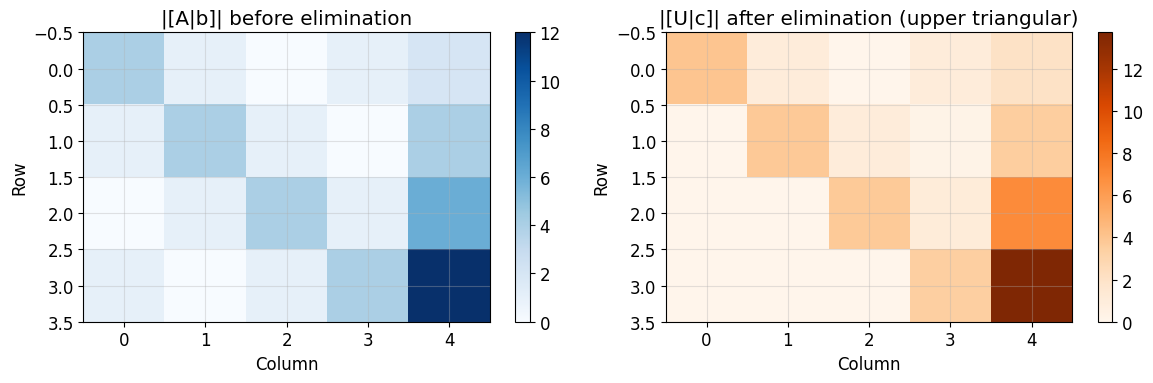

In [3]:
# --- 4x4 system: five-point Laplacian stencil ---
A4 = np.array([[ 4, -1,  0, -1],
               [-1,  4, -1,  0],
               [ 0, -1,  4, -1],
               [-1,  0, -1,  4]], dtype=float)
x_true = np.array([1.0, 2.0, 3.0, 4.0])
b4 = A4 @ x_true

print('System: A x = b  (known solution x* = [1, 2, 3, 4])')
print('b =', b4)
print()

x_ge, M_upper, pivots = gaussian_elim(A4, b4, verbose=True)

print('Solution found by Gaussian elimination:')
for i, xi in enumerate(x_ge):
    print(f'  x[{i}] = {xi:.14f}   error = {abs(xi - x_true[i]):.2e}')
print(f'Relative residual = {residual(A4, x_ge, b4):.2e}')
print(f'Numpy reference   : {np.linalg.solve(A4, b4)}')

# --- Pivoting stability demo: epsilon-system ---
print()
print('Pivoting stability demo (eps = 1e-15):')
eps = 1e-15
A_eps = np.array([[eps, 1.0], [1.0, 1.0]])
b_eps = np.array([1.0, 2.0])
x_ref = np.linalg.solve(A_eps, b_eps)

# Without pivoting (manual, first pivot = eps)
M_np = np.hstack([A_eps.copy(), b_eps.reshape(-1,1)])
m = M_np[1,0] / M_np[0,0]
M_np[1] -= m * M_np[0]
x2_np = (M_np[1,2]) / M_np[1,1]
x1_np = (M_np[0,2] - M_np[0,1]*x2_np) / M_np[0,0]
x_nopivot = np.array([x1_np, x2_np])

# With partial pivoting
x_pivot, _, _ = gaussian_elim(A_eps, b_eps)

print(f'  True solution      : x = {x_ref}')
print(f'  No pivoting        : x = {x_nopivot}  <-- catastrophic error!')
print(f'  Partial pivoting   : x = {x_pivot}  <-- correct')

# Visualisation: augmented matrix heatmap before and after elimination
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(np.abs(np.hstack([A4, b4.reshape(-1,1)])),
                     cmap='Blues', aspect='auto')
axes[0].set_title('|[A|b]| before elimination')
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.abs(M_upper), cmap='Oranges', aspect='auto')
axes[1].set_title('|[U|c]| after elimination (upper triangular)')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

### 2.2 Chemistry Application — CSTR with Simultaneous Reactions

**Background:** A continuous stirred-tank reactor (CSTR) operates at steady state with three
parallel/series reactions:

$$A \xrightarrow{k_1} B, \qquad A \xrightarrow{k_2} C, \qquad B \xrightarrow{k_3} D$$

Applying mole balances ($F \cdot c_j^{in} - F \cdot c_j + V \cdot r_j = 0$) for each species:

| Balance | Equation |
|---------|----------|
| Species A | $(F + V k_1 + V k_2)\,c_A = F\,c_{A0}$ |
| Species B | $-V k_1\,c_A + (F + V k_3)\,c_B = 0$ |
| Species C | $-V k_2\,c_A + F\,c_C = 0$ |
| Species D | $-V k_3\,c_B + F\,c_D = 0$ |

This $4 \times 4$ linear system $A_r\,\mathbf{c} = \mathbf{b}_r$ is solved for the outlet
concentrations $\mathbf{c} = [c_A, c_B, c_C, c_D]^T$.

**Parameters:**

| Symbol | Value | Units |
|--------|-------|-------|
| $F$ | 1.0 | L/min |
| $V$ | 10.0 | L |
| $k_1$ | 0.50 | min$^{-1}$ |
| $k_2$ | 0.30 | min$^{-1}$ |
| $k_3$ | 0.20 | min$^{-1}$ |
| $c_{A0}$ | 2.0 | mol/L |


CSTR coefficient matrix A_r:
[[ 9.  0.  0.  0.]
 [-5.  3.  0.  0.]
 [-3.  0.  1.  0.]
 [ 0. -2.  0.  1.]]
Right-hand side b_r: [2. 0. 0. 0.]

Outlet concentrations (Gaussian elimination):
  c_A = 0.222222 mol/L
  c_B = 0.370370 mol/L
  c_C = 0.666667 mol/L
  c_D = 0.740741 mol/L

Mole balance check: F*cA0 = 2.0000  |  F*sum(c_out) = 2.0000
Relative error = 1.11e-16
Relative residual ||A_r x - b_r|| / ||b_r|| = 6.21e-17


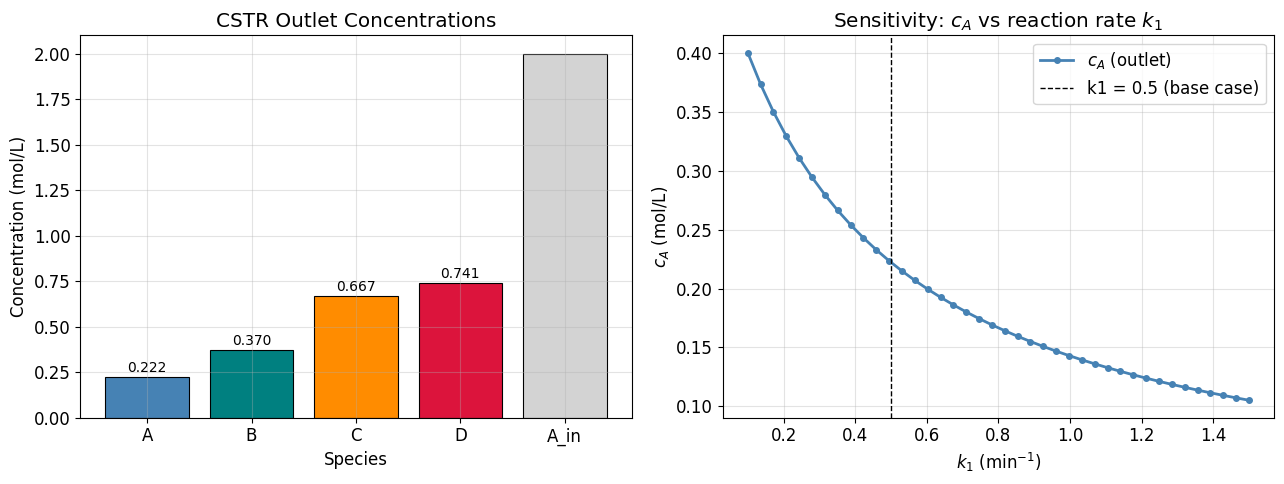

In [4]:
F   = 1.0    # L/min
V   = 10.0   # L
k1  = 0.50   # min^-1  (A -> B)
k2  = 0.30   # min^-1  (A -> C)
k3  = 0.20   # min^-1  (B -> D)
cA0 = 2.0    # mol/L  inlet concentration of A

# Build coefficient matrix A_r and rhs b_r
#  Row order: [cA, cB, cC, cD]
A_r = np.array([
    [ F + V*k1 + V*k2,      0.0,    0.0,  0.0],   # A balance
    [       -V*k1,     F + V*k3,    0.0,  0.0],   # B balance
    [       -V*k2,          0.0,      F,  0.0],   # C balance
    [         0.0,        -V*k3,    0.0,    F],   # D balance
], dtype=float)

b_r = np.array([F*cA0, 0.0, 0.0, 0.0])

print('CSTR coefficient matrix A_r:')
print(A_r)
print('Right-hand side b_r:', b_r)
print()

c_sol, _, _ = gaussian_elim(A_r, b_r)
cA, cB, cC, cD = c_sol

print('Outlet concentrations (Gaussian elimination):')
species = ['A', 'B', 'C', 'D']
for sp, c in zip(species, c_sol):
    print(f'  c_{sp} = {c:.6f} mol/L')
print()

# Mass balance check: total moles in = total moles out (F * cA0 = F * sum(c))
total_out = F * (cA + cB + cC + cD)
total_in  = F * cA0
print(f'Mole balance check: F*cA0 = {total_in:.4f}  |  F*sum(c_out) = {total_out:.4f}')
print(f'Relative error = {abs(total_out - total_in)/total_in:.2e}')

# Residual check
print(f'Relative residual ||A_r x - b_r|| / ||b_r|| = {residual(A_r, c_sol, b_r):.2e}')

# Visualisation: bar chart of outlet concentrations + flow diagram
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = ['steelblue', 'teal', 'darkorange', 'crimson']
bars = ax.bar(species, c_sol, color=colors, edgecolor='k', linewidth=0.8)
ax.bar(['A_in'], [cA0], color='lightgray', edgecolor='k', linewidth=0.8)
ax.set(xlabel='Species', ylabel='Concentration (mol/L)',
       title='CSTR Outlet Concentrations')
for bar, val in zip(bars, c_sol):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10)

ax = axes[1]
# Sensitivity: vary k1 from 0.1 to 1.5 and track cA
k1_vals = np.linspace(0.1, 1.5, 40)
cA_vals = []
for k1v in k1_vals:
    Av = np.array([[F+V*k1v+V*k2, 0, 0, 0],
                   [-V*k1v, F+V*k3, 0, 0],
                   [-V*k2, 0, F, 0],
                   [0, -V*k3, 0, F]], dtype=float)
    cv, _, _ = gaussian_elim(Av, b_r)
    cA_vals.append(cv[0])
ax.plot(k1_vals, cA_vals, 'o-', color='steelblue', ms=4, label='$c_A$ (outlet)')
ax.axvline(k1, color='k', ls='--', lw=1, label=f'k1 = {k1} (base case)')
ax.set(xlabel='$k_1$ (min$^{-1}$)', ylabel='$c_A$ (mol/L)',
       title='Sensitivity: $c_A$ vs reaction rate $k_1$')
ax.legend()

plt.tight_layout()
plt.show()

### 2.3 Telecommunications Application — Nodal Analysis of an RF Circuit

**Background:** In RF and microwave circuit design, **nodal analysis** (also called the
admittance-matrix method) formulates KCL at each independent node as a linear system:

$$Y \mathbf{v} = \mathbf{i}_s$$

where $Y$ is the **nodal admittance matrix**, $\mathbf{v}$ the vector of node voltages,
and $\mathbf{i}_s$ the vector of independent current sources.

For a resistive network with $n_b$ branches, the admittance matrix is assembled as:
- $Y_{ii} = \sum_k G_k$ (sum of conductances connected to node $i$)
- $Y_{ij} = -G_{ij}$ (negative conductance between nodes $i$ and $j$)

**4-node network** (nodes 1–4, reference = ground):

| Branch | Resistance | Conductance |
|--------|-----------|-------------|
| 1–2 | $R_{12} = 2\,\Omega$ | $G_{12} = 0.5\,\text{S}$ |
| 1–3 | $R_{13} = 4\,\Omega$ | $G_{13} = 0.25\,\text{S}$ |
| 1–4 | $R_{14} = 8\,\Omega$ | $G_{14} = 0.125\,\text{S}$ |
| 2–3 | $R_{23} = 4\,\Omega$ | $G_{23} = 0.25\,\text{S}$ |
| 2–4 | $R_{24} = 8\,\Omega$ | $G_{24} = 0.125\,\text{S}$ |
| 3–4 | $R_{34} = 4\,\Omega$ | $G_{34} = 0.25\,\text{S}$ |
| 1–gnd | $R_{1g} = 10\,\Omega$ | $G_{1g} = 0.1\,\text{S}$ |
| 2–gnd | $R_{2g} = 10\,\Omega$ | $G_{2g} = 0.1\,\text{S}$ |
| 3–gnd | $R_{3g} = 10\,\Omega$ | $G_{3g} = 0.1\,\text{S}$ |
| 4–gnd | $R_{4g} = 10\,\Omega$ | $G_{4g} = 0.1\,\text{S}$ |

Current sources: $I_1 = 2\,\text{A}$ (into node 1), $I_2 = 1\,\text{A}$ (into node 2).


Nodal admittance matrix Y (Siemens):
[[ 0.975 -0.5   -0.25  -0.125]
 [-0.5    0.975 -0.25  -0.125]
 [-0.25  -0.25   0.85  -0.25 ]
 [-0.125 -0.125 -0.25   0.6  ]]
Current source vector I_s (A): [2. 1. 0. 0.]

Node voltages (Gaussian elimination):
  V_1 = 8.755911 V
  V_2 = 8.077945 V
  V_3 = 6.818182 V
  V_4 = 6.347962 V

KCL verification (Y v - I_s should be zero):
  Node 1: -2.22e-16
  Node 2: 6.66e-16
  Node 3: 4.44e-16
  Node 4: 3.03e-16
Relative residual = 3.96e-16
Total power dissipated = 25.5898 W
Total power supplied   = 25.5898 W  (should match)


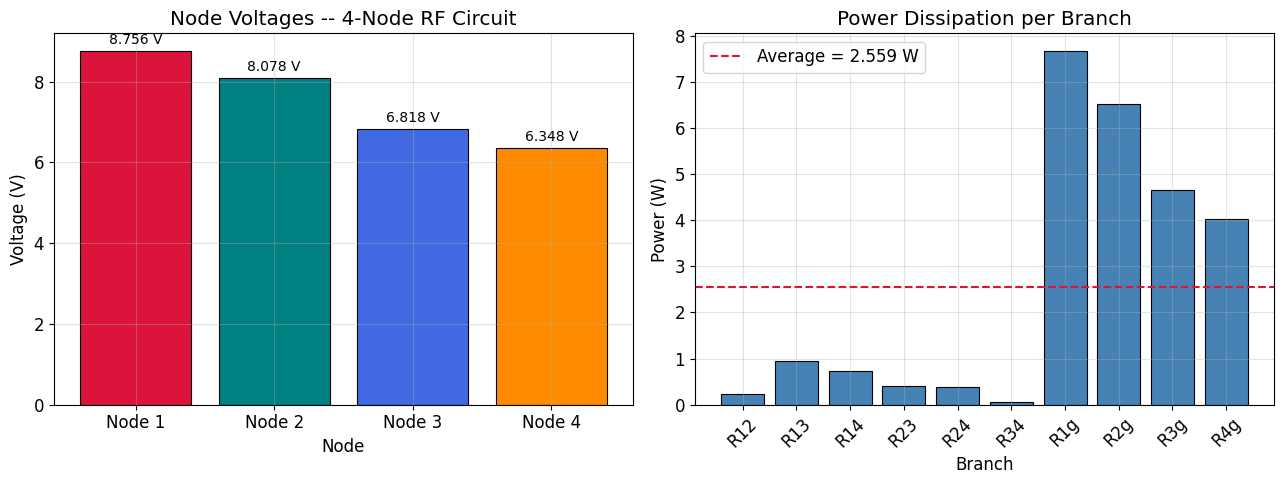

In [5]:
# Conductances
G12, G13, G14 = 0.5,   0.25,  0.125
G23, G24      = 0.25,  0.125
G34           = 0.25
G1g = G2g = G3g = G4g = 0.1

# Nodal admittance matrix Y (4x4)
Y = np.array([
    [ G12+G13+G14+G1g,  -G12,          -G13,          -G14         ],
    [-G12,               G12+G23+G24+G2g, -G23,         -G24        ],
    [-G13,              -G23,           G13+G23+G34+G3g, -G34       ],
    [-G14,              -G24,           -G34,          G14+G24+G34+G4g]
], dtype=float)

# Current source vector
I_s = np.array([2.0, 1.0, 0.0, 0.0])

print('Nodal admittance matrix Y (Siemens):')
print(np.round(Y, 4))
print('Current source vector I_s (A):', I_s)
print()

# Solve Y v = I_s
v_sol, _, _ = gaussian_elim(Y, I_s)

print('Node voltages (Gaussian elimination):')
for i, vi in enumerate(v_sol):
    print(f'  V_{i+1} = {vi:.6f} V')
print()

# Verify KCL at each node
print('KCL verification (Y v - I_s should be zero):')
kcl_err = Y @ v_sol - I_s
for i, e in enumerate(kcl_err):
    print(f'  Node {i+1}: {e:.2e}')
print(f'Relative residual = {residual(Y, v_sol, I_s):.2e}')

# Power dissipated in each branch
v = v_sol
powers = {
    'R12': G12*(v[0]-v[1])**2,
    'R13': G13*(v[0]-v[2])**2,
    'R14': G14*(v[0]-v[3])**2,
    'R23': G23*(v[1]-v[2])**2,
    'R24': G24*(v[1]-v[3])**2,
    'R34': G34*(v[2]-v[3])**2,
    'R1g': G1g*v[0]**2,
    'R2g': G2g*v[1]**2,
    'R3g': G3g*v[2]**2,
    'R4g': G4g*v[3]**2,
}
P_total = sum(powers.values())
P_sources = I_s[0]*v[0] + I_s[1]*v[1]
print(f'Total power dissipated = {P_total:.4f} W')
print(f'Total power supplied   = {P_sources:.4f} W  (should match)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
node_labels = ['Node 1', 'Node 2', 'Node 3', 'Node 4']
ax.bar(node_labels, v_sol, color=['crimson','teal','royalblue','darkorange'],
       edgecolor='k', lw=0.8)
ax.set(xlabel='Node', ylabel='Voltage (V)', title='Node Voltages -- 4-Node RF Circuit')
for i, vi in enumerate(v_sol):
    ax.text(i, vi + 0.02*max(v_sol), f'{vi:.3f} V', ha='center', fontsize=10)

ax = axes[1]
ax.bar(list(powers.keys()), list(powers.values()),
       color='steelblue', edgecolor='k', lw=0.8)
ax.axhline(P_total/len(powers), color='crimson', ls='--', lw=1.5,
           label=f'Average = {P_total/len(powers):.3f} W')
ax.set(xlabel='Branch', ylabel='Power (W)',
       title='Power Dissipation per Branch')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Computational Complexity and Residual Analysis

### 3.1 $\mathcal{O}(n^3)$ Scaling

The operation count for forward elimination is exactly:

$$\text{Multiplications} = \frac{n^3 - n}{3} \approx \frac{n^3}{3}$$

We verify this empirically by timing our implementation vs `numpy.linalg.solve` (LAPACK DGESV)
for matrix sizes $n = 10, 50, 100, 200, 500$.

### 3.2 Residual and Backward Error

The **relative residual** $\|A\mathbf{x} - \mathbf{b}\| / \|\mathbf{b}\|$ measures how well
the computed solution satisfies the original system. For a well-conditioned matrix it should
be close to machine epsilon ($\approx 10^{-16}$ for double precision).

The **condition number** $\kappa(A) = \|A\|\,\|A^{-1}\|$ governs the forward error:

$$\frac{\|\Delta\mathbf{x}\|}{\|\mathbf{x}\|} \leq \kappa(A)\,\frac{\|\mathbf{r}\|}{\|\mathbf{b}\|}$$


     n    GE time(s)    NP time(s)        Residual
--------------------------------------------------
    10    1.0008e-04    1.9667e-05      1.9306e-16
    30    4.2833e-04    1.2208e-05      2.2759e-16
    60    1.6174e-03    2.7125e-05      2.9938e-16
   100    4.6320e-03    8.7833e-05      4.8675e-16
   150    9.9486e-03    1.3162e-04      6.5797e-16
   200    1.8444e-02    2.2063e-04      6.9592e-16

Condition number (well-conditioned Laplacian) : 3.00
Condition number (near-singular matrix)       : 1.60e+05


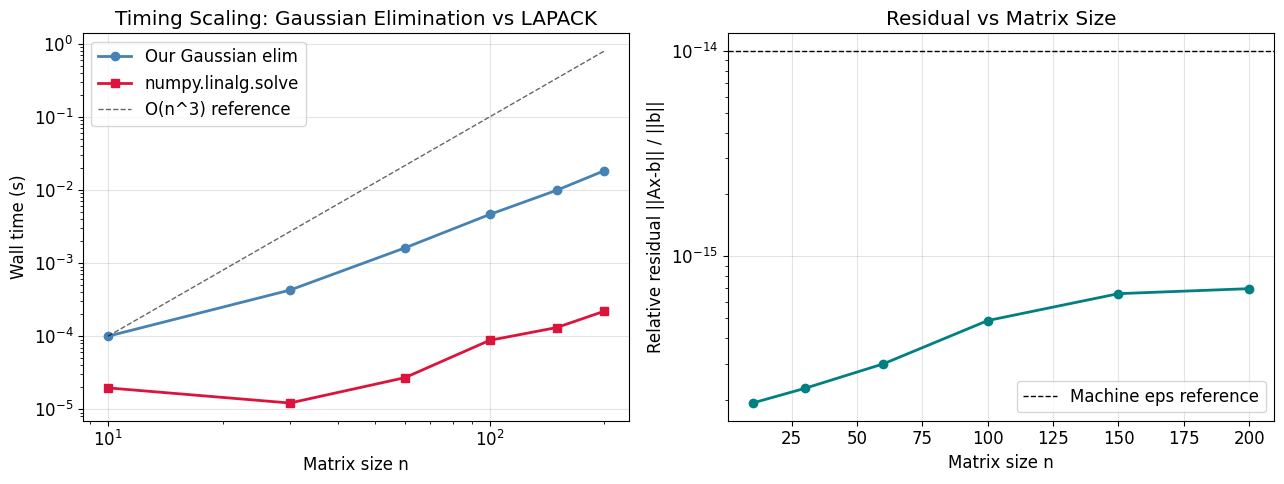

In [6]:
import time

sizes = [10, 30, 60, 100, 150, 200]
times_ge  = []
times_np  = []
resids_ge = []

rng = np.random.default_rng(42)

for n in sizes:
    # Random diagonally dominant matrix (guaranteed solvable)
    A_t = rng.standard_normal((n, n))
    A_t += n * np.eye(n)   # make diagonally dominant
    b_t = rng.standard_normal(n)

    t0 = time.perf_counter()
    x_t, _, _ = gaussian_elim(A_t, b_t)
    times_ge.append(time.perf_counter() - t0)
    resids_ge.append(residual(A_t, x_t, b_t))

    t0 = time.perf_counter()
    np.linalg.solve(A_t, b_t)
    times_np.append(time.perf_counter() - t0)

print('{:>6}  {:>12}  {:>12}  {:>14}'.format('n', 'GE time(s)', 'NP time(s)', 'Residual'))
print('-'*50)
for n, tge, tnp, res in zip(sizes, times_ge, times_np, resids_ge):
    print('{:>6}  {:>12.4e}  {:>12.4e}  {:>14.4e}'.format(n, tge, tnp, res))

# Condition number demo: well-conditioned vs ill-conditioned
print()
A_well = np.array([[4,-1,0,-1],[-1,4,-1,0],[0,-1,4,-1],[-1,0,-1,4]], dtype=float)
A_ill  = np.array([[1,1,1,1],[1,1.0001,1,1],[1,1,1.0001,1],[1,1,1,1.0001]], dtype=float)
print(f'Condition number (well-conditioned Laplacian) : {np.linalg.cond(A_well):.2f}')
print(f'Condition number (near-singular matrix)       : {np.linalg.cond(A_ill):.2e}')

# Plot: timing scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(sizes, times_ge, 'o-', color='steelblue', ms=6, label='Our Gaussian elim')
ax.loglog(sizes, times_np, 's-', color='crimson',   ms=6, label='numpy.linalg.solve')
n_ref = np.array(sizes, dtype=float)
ax.loglog(n_ref, times_ge[0]*(n_ref/sizes[0])**3, 'k--', lw=1, alpha=0.6, label='O(n^3) reference')
ax.set(xlabel='Matrix size n', ylabel='Wall time (s)',
       title='Timing Scaling: Gaussian Elimination vs LAPACK')
ax.legend()

ax = axes[1]
ax.semilogy(sizes, resids_ge, 'o-', color='teal', ms=6)
ax.axhline(1e-14, color='k', ls='--', lw=1, label='Machine eps reference')
ax.set(xlabel='Matrix size n', ylabel='Relative residual ||Ax-b|| / ||b||',
       title='Residual vs Matrix Size')
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Student Exercises

---

**Exercise 1 — Tridiagonal system**
A tridiagonal system (from 1D heat conduction with $n=6$ nodes) has the form:

$$\begin{bmatrix}
2 & -1 & & & \\
-1 & 2 & -1 & & \\
& \ddots & \ddots & \ddots & \\
& & -1 & 2 & -1 \\
& & & -1 & 2
\end{bmatrix} \mathbf{T} = \mathbf{q}$$

with $\mathbf{q} = [100, 0, 0, 0, 0, 200]^T$ (boundary heat fluxes).
a) Solve with `gaussian_elim`. b) Why would a specialised **Thomas algorithm** ($\mathcal{O}(n)$)
be preferable for large $n$?

---

**Exercise 2 — Multiple right-hand sides**
The same matrix $A$ must be solved for three different load vectors $\mathbf{b}_1, \mathbf{b}_2, \mathbf{b}_3$
(e.g., three load cases in a structural problem). Modify `gaussian_elim` to accept a matrix $B$
instead of a vector $b$ and solve all systems simultaneously in one forward elimination pass.
Compare the cost to calling `gaussian_elim` three times separately.

---

**Exercise 3 — Reaction network expansion**
Extend the CSTR example to include a **reversible reaction** $B \rightleftharpoons D$
(forward rate $k_3$, reverse rate $k_4 = 0.05$ min$^{-1}$). Write the new $4 \times 4$ system,
solve it, and compare the outlet concentrations to the irreversible case.

---

**Exercise 4 — Larger RF network**
Add a fifth node to the circuit in Example 2.3 connected to nodes 2, 3, and ground via
$R_{25} = 6\,\Omega$, $R_{35} = 8\,\Omega$, $R_{5g} = 20\,\Omega$.
Assemble the new $5 \times 5$ admittance matrix, solve, and verify power balance.

---

**Exercise 5 — Ill-conditioning exploration**
Construct a **Hilbert matrix** $H_{ij} = 1/(i+j-1)$ for $n = 4, 8, 12$.
a) Compute the condition number for each $n$. b) Solve $H\mathbf{x} = \mathbf{b}$
(choose $\mathbf{b} = H \cdot \mathbf{1}$ so the true solution is $\mathbf{x} = \mathbf{1}$).
c) Plot the true error vs $n$ and observe how ill-conditioning degrades accuracy despite
partial pivoting.


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers*
   (7th ed., pp. 218–257). McGraw-Hill Education.
   *Chapters 9–10 present Gaussian elimination and partial pivoting in full detail, including
   the operation-count derivation in Section 9.4 and the ill-conditioning discussion in
   Section 9.7 that motivates the condition number analysis in Section 3.2.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis*
   (10th ed., pp. 353–400). Cengage Learning.
   *Chapter 6 gives a rigorous treatment of Gaussian elimination with scaled partial pivoting,
   backward error analysis (Theorem 6.17), and the $\mathcal{O}(n^3/3)$ operation count
   proven in Theorem 6.5.*

3. **Golub, G. H., & Van Loan, C. F.** (2013). *Matrix Computations* (4th ed., pp. 111–145).
   Johns Hopkins University Press.
   *Section 3.4 analyses the growth factor for partial pivoting and proves that the relative
   residual satisfies $\|\mathbf{r}\|/\|\mathbf{b}\| \leq \mathcal{O}(\varepsilon_\text{mach})
   \kappa(A)$, which is the bound stated in Section 3.2 of this notebook.*

4. **Fogler, H. S.** (2016). *Elements of Chemical Reaction Engineering*
   (5th ed., pp. 147–165). Prentice Hall.
   *Chapter 5 derives steady-state CSTR mole balances for reaction networks, providing the
   physical basis for Example 2.2. The matrix formulation follows the linearisation approach
   in Section 5.3.*

5. **Pozar, D. M.** (2012). *Microwave Engineering* (4th ed., pp. 172–193). Wiley.
   *Section 4.4 introduces the admittance matrix formulation for microwave circuits,
   including the assembly rules for $Y_{ii}$ and $Y_{ij}$ used to construct the nodal
   admittance matrix in Example 2.3.*
